In [1]:
# Libs
from time import gmtime, strftime
import xarray as xr
import numpy as np

# Locals
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
import oggm.cfg as cfg
from oggm.shop import gcm_climate

In [2]:
# Initialize OGGM and set up the default run parameters
cfg.initialize(logging_level='WARNING')

# change border around the individual glaciers
cfg.PARAMS['border'] = 80

# Use Multiprocessing
cfg.PARAMS['use_multiprocessing'] = True

# For hydro output
cfg.PARAMS['store_model_geometry'] = True

# Local working directory (where OGGM will write its output)
cfg.PATHS['working_dir'] = '/home/usman/Music/GeeMap/OGGM/data'

# RGI glaciers: Ngojumba and Khumbu
rgi_ids = utils.get_rgi_glacier_entities(['RGI60-14.02192'])

# Go - get the pre-processed glacier directories
# in OGGM v1.6 you have to explicitly indicate the url from where you want to start from
# we will use here the elevation band flowlines which are much simpler than the centerlines
gdirs = workflow.init_glacier_directories(rgi_ids, from_prepro_level=5, prepro_base_url=DEFAULT_BASE_URL)

2025-01-08 18:35:17: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-01-08 18:35:17: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-01-08 18:35:17: oggm.cfg: Multiprocessing: using all available processors (N=16)
2025-01-08 18:35:18: oggm.cfg: Multiprocessing switched ON after user settings.
2025-01-08 18:35:18: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-01-08 18:35:20: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-01-08 18:35:20: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [3]:
gdirs

[<oggm.GlacierDirectory>
   RGI id: RGI60-14.02192
   Region: 14: South Asia West
   Subregion: 14-02: Karakoram                       
   Name: Karambar Glacier
   Glacier type: Glacier
   Terminus type: Land-terminating
   Status: Glacier or ice cap
   Area: 81.704 km2
   Lon, Lat: (74.2238, 36.6159)
   Grid (nx, ny): (318, 252)
   Grid (dx, dy): (137.0, -137.0)]

In [3]:
all_GCM = ['gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1',
           'mpi-esm1-2-hr_r1i1p1f1',
           'mri-esm2-0_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2']

# define the SSP scenarios
all_scenario = ['ssp126', 'ssp370', 'ssp585']

for GCM in all_GCM:
    for ssp in all_scenario:
        # we will pretend that 'mpi-esm1-2-hr_r1i1p1f1' is missing for `ssp370`
        # to later show how to deal with missing values, 
        # if you want to use this
        # code you can of course remove the "if" and just download all GCMs and SSPS 
        # if (ssp == 'ssp370') & (GCM=='mpi-esm1-2-hr_r1i1p1f1'):
        #     pass
        # else:
            # Download and process them:
            workflow.execute_entity_task(gcm_climate.process_monthly_isimip_data, gdirs, 
                                         ssp = ssp,
                                         # gcm ensemble -> you can choose another one
                                         member=GCM,
                                         # recognize the climate file for later
                                         output_filesuffix=f'_{GCM}_{ssp}'
                                         );
            
# you could create a similar workflow with CMIP5 or CMIP6 

2025-01-08 15:24:38: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:25:22: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:25:33: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:31:02: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:36:22: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:41:30: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:41:48: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:42:31: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:48:04: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-01-08 15:53:29: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1

In [4]:
for GCM in all_GCM:
    for scen in all_scenario:
        rid = '_{}_{}'.format(GCM, scen)
        try:  # check if (GCM, scen) combination exists
            workflow.execute_entity_task(tasks.run_with_hydro, gdirs,
                                         run_task=tasks.run_from_climate_data,
                                         ys=2020,  # star year of our projection runs
                                         climate_filename='gcm_data',  # use gcm_data, not climate_historical
                                         climate_input_filesuffix=rid,  # use the chosen GCM and scenario
                                         init_model_filesuffix='_spinup_historical',  # this is important! Start from 2020 glacier
                                         output_filesuffix=rid,  # the filesuffix of the resulting file, so we can find it later
                                         store_monthly_hydro=True
                                        );

        except FileNotFoundError:
            # if a certain scenario is not available for a GCM we land here
            # and we inidcate this by printing a message so the user knows
            # this scenario is missing
            # (in this case of course, the file actually is available, but we just pretend that it is not...)
            print('No ' + GCM +' run with scenario ' + scen + ' available!')

2025-01-08 16:14:15: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:17: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:17: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:18: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:19: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:20: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:21: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:23: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:24: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:25: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:25: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-01-08 16:14:26: oggm.workfl

In [5]:
file_id  = '_{}_{}'.format(all_GCM[0], all_scenario[0])
ds = utils.compile_run_output(gdirs, input_filesuffix=file_id)
ds

2025-01-08 16:16:40: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:16:40: oggm.utils: Applying compile_run_output on 1 gdirs.


<xarray.Dataset> Size: 61kB
Dimensions:                       (time: 82, rgi_id: 1, month_2d: 12)
Coordinates:
  * time                          (time) float64 656B 2.02e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 56B 'RGI60-14.02192'
    hydro_year                    (time) int64 656B 2020 2021 2022 ... 2100 2101
    hydro_month                   (time) int64 656B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 656B 2020 2021 2022 ... 2100 2101
    calendar_month                (time) int64 656B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
Data variables: (12/24)
    volume                        (time, rgi_id) float64 656B 7.538e+09 ... 6...
    volume_bsl                    (time, rgi_id) float64 656B 0.0 0.0 ... 0.0
    volume_bwl                    (time, rgi_id) float64 656B 0.0 0.0 ... 0.0
    area                          (time, rgi_id) float64 656B 8.188e+07 ... 8...
    length                        (time, rgi_id) float64 656B 1.781e+04 ... 1...
    calving                       (time, rgi_id) float64 656B 0.0 0.0 ... 0.0
    ...                            ...
    liq_prcp_on_glacier_monthly   (time, month_2d, rgi_id) float64 8kB 0.0 .....
    snowfall_off_glacier_monthly  (time, month_2d, rgi_id) float64 8kB 1.43e+...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float64 8kB 1.579e...
    water_level                   (rgi_id) float64 8B 0.0
    glen_a                        (rgi_id) float64 8B 6.43e-24
    fs                            (rgi_id) float64 8B 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-08 11:16:40

In [7]:
ds['volume'].loc[{'time': [2030, 2040], 'rgi_id': ['RGI60-14.02192' ]}]

<xarray.DataArray 'volume' (time: 2, rgi_id: 1)> Size: 16B
array([[7.40399624e+09],
       [7.32354753e+09]])
Coordinates:
  * time            (time) float64 16B 2.03e+03 2.04e+03
  * rgi_id          (rgi_id) <U14 56B 'RGI60-14.02192'
    hydro_year      (time) int64 16B 2030 2040
    hydro_month     (time) int64 16B 4 4
    calendar_year   (time) int64 16B 2030 2040
    calendar_month  (time) int64 16B 1 1
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [8]:
ds.coords['GCM'] = all_GCM[0]
ds.coords['GCM'].attrs['description'] = 'Global Circulation Model'
ds

<xarray.Dataset> Size: 61kB
Dimensions:                       (time: 82, rgi_id: 1, month_2d: 12)
Coordinates:
  * time                          (time) float64 656B 2.02e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 56B 'RGI60-14.02192'
    hydro_year                    (time) int64 656B 2020 2021 2022 ... 2100 2101
    hydro_month                   (time) int64 656B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 656B 2020 2021 2022 ... 2100 2101
    calendar_month                (time) int64 656B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    GCM                           <U18 72B 'gfdl-esm4_r1i1p1f1'
Data variables: (12/24)
    volume                        (time, rgi_id) float64 656B 7.538e+09 ... 6...
    volume_bsl                    (time, rgi_id) float64 656B 0.0 0.0 ... 0.0
    volume_bwl                    (time, rgi_id) float64 656B 0.0 0.0 ... 0.0
    area                          (time, rgi_id) float64 656B 8.188e+07 ... 8...
    length                        (time, rgi_id) float64 656B 1.781e+04 ... 1...
    calving                       (time, rgi_id) float64 656B 0.0 0.0 ... 0.0
    ...                            ...
    liq_prcp_on_glacier_monthly   (time, month_2d, rgi_id) float64 8kB 0.0 .....
    snowfall_off_glacier_monthly  (time, month_2d, rgi_id) float64 8kB 1.43e+...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float64 8kB 1.579e...
    water_level                   (rgi_id) float64 8B 0.0
    glen_a                        (rgi_id) float64 8B 6.43e-24
    fs                            (rgi_id) float64 8B 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-08 11:16:40

In [9]:
ds = ds.expand_dims('GCM')
ds

<xarray.Dataset> Size: 61kB
Dimensions:                       (time: 82, rgi_id: 1, month_2d: 12, GCM: 1)
Coordinates:
  * time                          (time) float64 656B 2.02e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 56B 'RGI60-14.02192'
    hydro_year                    (time) int64 656B 2020 2021 2022 ... 2100 2101
    hydro_month                   (time) int64 656B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 656B 2020 2021 2022 ... 2100 2101
    calendar_month                (time) int64 656B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
  * GCM                           (GCM) <U18 72B 'gfdl-esm4_r1i1p1f1'
Data variables: (12/24)
    volume                        (GCM, time, rgi_id) float64 656B 7.538e+09 ...
    volume_bsl                    (GCM, time, rgi_id) float64 656B 0.0 ... 0.0
    volume_bwl                    (GCM, time, rgi_id) float64 656B 0.0 ... 0.0
    area                          (GCM, time, rgi_id) float64 656B 8.188e+07 ...
    length                        (GCM, time, rgi_id) float64 656B 1.781e+04 ...
    calving                       (GCM, time, rgi_id) float64 656B 0.0 ... 0.0
    ...                            ...
    liq_prcp_on_glacier_monthly   (GCM, time, month_2d, rgi_id) float64 8kB 0...
    snowfall_off_glacier_monthly  (GCM, time, month_2d, rgi_id) float64 8kB 1...
    snowfall_on_glacier_monthly   (GCM, time, month_2d, rgi_id) float64 8kB 1...
    water_level                   (GCM, rgi_id) float64 8B 0.0
    glen_a                        (GCM, rgi_id) float64 8B 6.43e-24
    fs                            (GCM, rgi_id) float64 8B 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.2
    calendar:       365-day no leap
    creation_date:  2025-01-08 11:16:40

In [10]:
ds_all = []  # in this array all datasets going to be stored with additional coordinates GCM and SCENARIO
creation_date = strftime("%Y-%m-%d %H:%M:%S", gmtime())  # here add the current time for info
for GCM in all_GCM:  # loop through all GCMs
    for scen in all_scenario:  # loop through all SSPs
        try:  # check if GCM, SCENARIO combination exists
            rid = '_{}_{}'.format(GCM, scen)  # put together the same filesuffix which was used during the projection runs

            ds_tmp = utils.compile_run_output(gdirs, input_filesuffix=rid)  # open one model run

            ds_tmp.coords['GCM'] = GCM  # add GCM as a coordinate
            ds_tmp.coords['GCM'].attrs['description'] = 'used Global circulation Model'  # add a description for GCM
            ds_tmp = ds_tmp.expand_dims("GCM")  # add GCM as a dimension to all Data variables

            ds_tmp.coords['SCENARIO'] = scen  # add scenario (here ssp) as a coordinate
            ds_tmp.coords['SCENARIO'].attrs['description'] = 'used scenario (here SSPs)'
            ds_tmp = ds_tmp.expand_dims("SCENARIO")  # add SSO as a dimension to all Data variables

            ds_tmp.attrs['creation_date'] = creation_date  # also add todays date for info
            ds_all.append(ds_tmp)  # add the dataset with extra coordinates to our final ds_all array

        except RuntimeError as err:  # here we land if an error occured
            if str(err) == 'Found no valid glaciers!':  # This is the error message if the GCM, SCENARIO (here ssp) combination does not exist
                print(f'No data for GCM {GCM} with SCENARIO {scen} found!')  # print a descriptive message
            else:
                raise RuntimeError(err)  # if an other error occured we just raise it

2025-01-08 16:28:59: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:28:59: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-01-08 16:28:59: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:28:59: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-01-08 16:28:59: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:28:59: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-01-08 16:28:59: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:28:59: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-01-08 16:28:59: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:28:59: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-01-08 16:28:59: oggm.utils: Applying global task compile_run_output on 1 glaciers
2025-01-08 16:28:59: oggm.utils: Applying compile_run_output on 1 gdirs.
2025-01-08 16:28:59: oggm.utils: Applyin

In [11]:
ds_all

[<xarray.Dataset> Size: 61kB
 Dimensions:                       (time: 82, rgi_id: 1, month_2d: 12,
                                    SCENARIO: 1, GCM: 1)
 Coordinates:
   * time                          (time) float64 656B 2.02e+03 ... 2.101e+03
   * rgi_id                        (rgi_id) <U14 56B 'RGI60-14.02192'
     hydro_year                    (time) int64 656B 2020 2021 2022 ... 2100 2101
     hydro_month                   (time) int64 656B 4 4 4 4 4 4 ... 4 4 4 4 4 4
     calendar_year                 (time) int64 656B 2020 2021 2022 ... 2100 2101
     calendar_month                (time) int64 656B 1 1 1 1 1 1 ... 1 1 1 1 1 1
   * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
     calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
   * GCM                           (GCM) <U18 72B 'gfdl-esm4_r1i1p1f1'
   * SCENARIO                      (SCENARIO) <U6 24B 'ssp126'
 Data variables: (12/24)
     volume                       

In [12]:
ds_merged = xr.combine_by_coords(ds_all, fill_value=np.nan)  # define how the missing GCM, SCENARIO combinations should be filled

In [13]:
ds_merged.to_netcdf('/home/usman/Music/GeeMap/Results/merged_GCM_projections.nc')

In [14]:
ds_merged.to_netcdf('merged_GCM_projections.nc')

In [15]:
with xr.open_dataset('merged_GCM_projections.nc') as ds:
    ds_merged = ds

In [16]:
# the missing values were filled with np.NaN values for all time points and glaciers 
assert np.all(np.isnan(ds_merged['volume'].sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')))

AssertionError: 

In [17]:
# So, what happens to the missing GCM and ssp if we just do the sum? 
ds_total_volume_wrong = ds_merged['volume'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          keep_attrs=True)  # keep the variable descriptions       
ds_total_volume_wrong.sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')

<xarray.DataArray 'volume' (time: 82)> Size: 656B
array([7.53835204e+09, 7.54016091e+09, 7.55208305e+09, 7.52370980e+09,
       7.50995810e+09, 7.45795535e+09, 7.45524596e+09, 7.45140447e+09,
       7.41999006e+09, 7.38452064e+09, 7.36823196e+09, 7.38054435e+09,
       7.38927581e+09, 7.35535745e+09, 7.34993092e+09, 7.36056089e+09,
       7.39506581e+09, 7.39893799e+09, 7.38845527e+09, 7.45203254e+09,
       7.46349375e+09, 7.45558391e+09, 7.38851420e+09, 7.35487509e+09,
       7.39001462e+09, 7.36901385e+09, 7.32590743e+09, 7.31324457e+09,
       7.31432415e+09, 7.23148325e+09, 7.20862877e+09, 7.22905658e+09,
       7.25878943e+09, 7.28149452e+09, 7.27511533e+09, 7.24482237e+09,
       7.22609794e+09, 7.20221655e+09, 7.21034366e+09, 7.16426554e+09,
       7.12389524e+09, 7.11395019e+09, 7.04739014e+09, 7.03991446e+09,
       7.01890476e+09, 6.94572910e+09, 6.89266502e+09, 6.84644374e+09,
       6.80516047e+09, 6.76732105e+09, 6.71443443e+09, 6.66904470e+09,
       6.63330503e+09, 6.59287538e+09, 6.59201889e+09, 6.58126391e+09,
       6.52825090e+09, 6.47549136e+09, 6.39295275e+09, 6.33319483e+09,
       6.26648921e+09, 6.18232449e+09, 6.12541382e+09, 6.11574499e+09,
       6.07411046e+09, 6.00647541e+09, 5.94445888e+09, 5.94768091e+09,
       5.86263038e+09, 5.82301515e+09, 5.79749789e+09, 5.70242025e+09,
       5.60613176e+09, 5.56205644e+09, 5.46674391e+09, 5.44231694e+09,
       5.38450837e+09, 5.30770397e+09, 5.20883231e+09, 5.14453205e+09,
       5.09420767e+09, 5.01045450e+09])
Coordinates:
  * time            (time) float64 656B 2.02e+03 2.021e+03 ... 2.1e+03 2.101e+03
    hydro_year      (time) int64 656B ...
    hydro_month     (time) int64 656B ...
    calendar_year   (time) int64 656B ...
    calendar_month  (time) int64 656B ...
    GCM             <U22 88B 'mpi-esm1-2-hr_r1i1p1f1'
    SCENARIO        <U6 24B 'ssp370'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [19]:
ds_total_volume = ds_merged['volume'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          skipna=True,  # ignore nan values
                                          # important, we need values for every glacier (here 2) to do the sum
                                          # if some have NaN, the sum should also be NaN (if you don't set min_count, the sum will be 0, which is bad)
                                          min_count=len(ds_merged.rgi_id), 
                                          keep_attrs=True)  # keep the variable descriptions   
# perfect, now, the `NaN` is preserved!
assert np.all(np.isnan(ds_total_volume.sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')))

AssertionError: 

In [30]:
ds_total_volume

<xarray.DataArray 'volume' (SCENARIO: 3, GCM: 5, time: 82)> Size: 10kB
array([[[7.53835204e+09, 7.58927535e+09, 7.56207324e+09, ...,
         6.40715197e+09, 6.37883568e+09, 6.36014597e+09],
        [7.53835204e+09, 7.58084305e+09, 7.57541904e+09, ...,
         6.32122365e+09, 6.33599282e+09, 6.35665599e+09],
        [7.53835204e+09, 7.53630013e+09, 7.53971232e+09, ...,
         7.45364477e+09, 7.46273074e+09, 7.47258884e+09],
        [7.53835204e+09, 7.55258272e+09, 7.56540501e+09, ...,
         7.04582738e+09, 7.06299823e+09, 7.02845321e+09],
        [7.53835204e+09, 7.48773738e+09, 7.44567735e+09, ...,
         4.71017582e+09, 4.68684685e+09, 4.59669513e+09]],

       [[7.53835204e+09, 7.48694739e+09, 7.50525095e+09, ...,
         5.13683731e+09, 5.07820040e+09, 5.04805254e+09],
        [7.53835204e+09, 7.53460539e+09, 7.46837359e+09, ...,
         4.44928509e+09, 4.38415499e+09, 4.25767327e+09],
        [7.53835204e+09, 7.54016091e+09, 7.55208305e+09, ...,
         5.14453205e+09, 5.09420767e+09, 5.01045450e+09],
        [7.53835204e+09, 7.52827742e+09, 7.54365064e+09, ...,
         5.74545456e+09, 5.66358060e+09, 5.68866872e+09],
        [7.53835204e+09, 7.52094350e+09, 7.50754103e+09, ...,
         2.05007163e+09, 1.98139624e+09, 1.89450301e+09]],

       [[7.53835204e+09, 7.51592065e+09, 7.53413918e+09, ...,
         4.56458349e+09, 4.47403151e+09, 4.44318309e+09],
        [7.53835204e+09, 7.52001961e+09, 7.51821697e+09, ...,
         2.95538461e+09, 2.86480776e+09, 2.78139695e+09],
        [7.53835204e+09, 7.50955856e+09, 7.52193585e+09, ...,
         4.46979560e+09, 4.38037417e+09, 4.28627842e+09],
        [7.53835204e+09, 7.53632666e+09, 7.53410566e+09, ...,
         4.85610369e+09, 4.77610060e+09, 4.69060933e+09],
        [7.53835204e+09, 7.56707727e+09, 7.55983076e+09, ...,
         1.02806397e+09, 9.64004581e+08, 9.53037680e+08]]],
      shape=(3, 5, 82))
Coordinates:
  * time            (time) float64 656B 2.02e+03 2.021e+03 ... 2.1e+03 2.101e+03
    hydro_year      (time) int64 656B ...
    hydro_month     (time) int64 656B ...
    calendar_year   (time) int64 656B ...
    calendar_month  (time) int64 656B ...
  * GCM             (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'ukesm1-0-ll_r1i...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [20]:
ds_total_volume_median = ds_total_volume.median(dim='GCM',  # over which dimension the median should be calculated
                                            skipna=True,  # ignore nan values
                                            keep_attrs=True)  # keep all variable descriptions
ds_total_volume_median

<xarray.DataArray 'volume' (SCENARIO: 3, time: 82)> Size: 2kB
array([[7.53835204e+09, 7.55258272e+09, 7.56207324e+09, 7.55381089e+09,
        7.55341565e+09, 7.54056123e+09, 7.53617447e+09, 7.49323739e+09,
        7.51544070e+09, 7.49184362e+09, 7.49886293e+09, 7.46126482e+09,
        7.42451687e+09, 7.41407962e+09, 7.41281978e+09, 7.38934086e+09,
        7.37489582e+09, 7.37774484e+09, 7.37001616e+09, 7.34309608e+09,
        7.32354753e+09, 7.28739104e+09, 7.34374508e+09, 7.38469991e+09,
        7.42311597e+09, 7.40271474e+09, 7.36139478e+09, 7.29703001e+09,
        7.29613681e+09, 7.28430216e+09, 7.26012450e+09, 7.22920687e+09,
        7.20723796e+09, 7.19121423e+09, 7.20644504e+09, 7.18589361e+09,
        7.19680087e+09, 7.19812782e+09, 7.17458089e+09, 7.14890011e+09,
        7.11708290e+09, 7.06853163e+09, 7.08380693e+09, 7.04641908e+09,
        7.06274474e+09, 7.04989213e+09, 7.04424236e+09, 7.04136446e+09,
        7.04624856e+09, 7.02303851e+09, 7.02211418e+09, 6.99833975e+09,
        6.96227295e+09, 6.94913768e+09, 6.94208105e+09, 6.94626483e+09,
        6.92476425e+09, 6.88879594e+09, 6.86507991e+09, 6.82597431e+09,
        6.78162711e+09, 6.77753465e+09, 6.75700855e+09, 6.76642677e+09,
        6.75072929e+09, 6.70281026e+09, 6.64617493e+09, 6.60138653e+09,
        6.63274707e+09, 6.63423385e+09, 6.67737657e+09, 6.64918369e+09,
        6.62054345e+09, 6.58653655e+09, 6.60146652e+09, 6.54622037e+09,
        6.50051390e+09, 6.50505470e+09, 6.43532838e+09, 6.40715197e+09,
...
        7.51627705e+09, 7.50149103e+09, 7.46608190e+09, 7.41329482e+09,
        7.42327624e+09, 7.41979949e+09, 7.35075303e+09, 7.36795893e+09,
        7.38970619e+09, 7.36553893e+09, 7.34528813e+09, 7.32764817e+09,
        7.29312208e+09, 7.27843953e+09, 7.23077829e+09, 7.18930494e+09,
        7.17258673e+09, 7.14539362e+09, 7.13418927e+09, 7.14779972e+09,
        7.13648335e+09, 7.11628837e+09, 7.06753230e+09, 7.05604837e+09,
        7.01649978e+09, 7.01572916e+09, 6.99015955e+09, 6.92432383e+09,
        6.87583411e+09, 6.81743954e+09, 6.75852821e+09, 6.74323927e+09,
        6.73134818e+09, 6.68817853e+09, 6.71594261e+09, 6.75520039e+09,
        6.72373114e+09, 6.66633829e+09, 6.60523624e+09, 6.54364221e+09,
        6.45983614e+09, 6.46105662e+09, 6.43682650e+09, 6.38024515e+09,
        6.30871282e+09, 6.29672043e+09, 6.28899689e+09, 6.20884673e+09,
        6.17943425e+09, 6.18605270e+09, 6.18214782e+09, 6.13391609e+09,
        6.03861611e+09, 6.00633317e+09, 5.93861614e+09, 5.87575208e+09,
        5.81018349e+09, 5.75033270e+09, 5.74664517e+09, 5.69937767e+09,
        5.61080609e+09, 5.58731719e+09, 5.47990939e+09, 5.40547092e+09,
        5.28442116e+09, 5.20911537e+09, 5.12992396e+09, 5.06986243e+09,
        5.00342220e+09, 4.92418700e+09, 4.80958879e+09, 4.71914831e+09,
        4.63470928e+09, 4.53978003e+09, 4.52247668e+09, 4.46979560e+09,
        4.38037417e+09, 4.28627842e+09]])
Coordinates:
  * time            (time) float64 656B 2.02e+03 2.021e+03 ... 2.1e+03 2.101e+03
    hydro_year      (time) int64 656B ...
    hydro_month     (time) int64 656B ...
    calendar_year   (time) int64 656B ...
    calendar_month  (time) int64 656B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [21]:
import matplotlib.pyplot as plt

In [22]:
# estimate the minimum volume for each time step and scenario over the GCMs
ds_total_volume_min = ds_total_volume.min(dim='GCM', keep_attrs=True,skipna=True)
# estimate the 25th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p25 = ds_total_volume.quantile(0.25, dim='GCM', keep_attrs=True,skipna=True)
# estimate the 50th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p50 = ds_total_volume.quantile(0.5, dim='GCM', keep_attrs=True,skipna=True)
# this is the same as the median -> Let's check
np.testing.assert_allclose(ds_total_volume_median,ds_total_volume_p50)
# estimate the 75th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p75 = ds_total_volume.quantile(0.75, dim='GCM', keep_attrs=True,skipna=True)
# estimate the maximum volume for each time step and scenario over the GCMs
ds_total_volume_max = ds_total_volume.max(dim='GCM', keep_attrs=True,skipna=True)

# Think twice if it is appropriate to compute a mean/std over your GCM sample, is it Gaussian distributed?
# Otherwise use instead median and percentiles or total range
ds_total_volume_mean = ds_total_volume.mean(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_std = ds_total_volume.std(dim='GCM', keep_attrs=True,
                                            skipna=True)

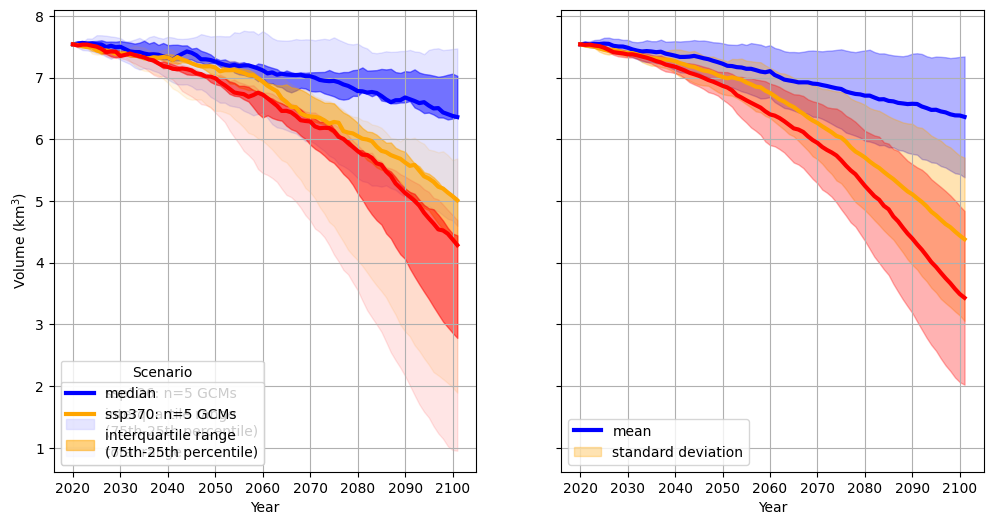

In [23]:
color_dict={'ssp126':'blue', 'ssp370':'orange', 'ssp585':'red'}


fig, axs = plt.subplots(1,2, figsize=(12,6), 
                        sharey=True # we want to share the y axis betweeen the subplots
                       )
for scenario in color_dict.keys():
    # get amount of GCMs per Scenario to add it to the legend:
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario)/1e9,  # m3 -> km3
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario],lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario)/1e9,
                        color=color_dict[scenario],
                        alpha=0.5,
                        label='interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario)/1e9,
                        color=color_dict[scenario],
                        alpha=0.1,
                        label='total range')


for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                 ds_total_volume_mean.sel(SCENARIO=scenario)/1e9,  # m3 -> km3
                 color=color_dict[scenario],
                 label='mean',lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario)/1e9 - ds_total_volume_std.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario)/1e9 + ds_total_volume_std.sel(SCENARIO=scenario)/1e9,
                        alpha=0.3,
                        color=color_dict[scenario],
                       label='standard deviation')
    
for ax in axs:
    # get all handles and labels and then create two different legends
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # we want to have two legends, let's save the first one
        # which just shows the colors and the different SSPs here 
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario') 
        ax.set_ylabel(r'Volume (km$^3$)')
        # create the second one, that shows the different statistical estimates
        ax.legend([handles[0],handles[3],handles[4]],
                  ['median',labels[3],labels[4]], loc='lower left')
        # we need to allow for two legend, this is done like that
        ax.add_artist(leg1)
    else:
        # for the second plot, we only want to have the legend for mean and std
        ax.legend(handles[::3], labels[::3], loc='lower left') 
    ax.set_xlabel('Year');
    ax.grid()

Text(0.5, 1.0, 'ssp585')

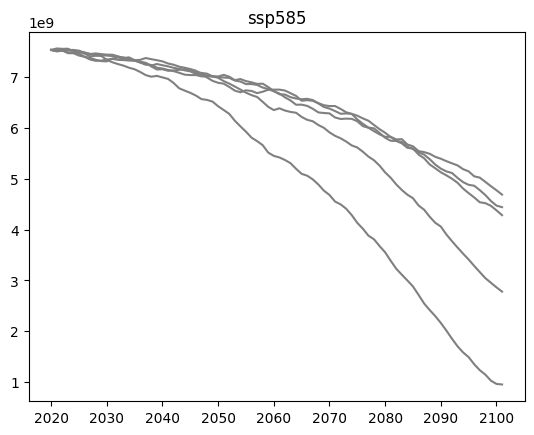

In [24]:
# for example, if there are just 5 GCMs, maybe you can just show all of them?
for gcm in all_GCM: 
    plt.plot(ds_total_volume.sel(SCENARIO=scenario).time,
            ds_total_volume.sel(SCENARIO=scenario, GCM=gcm),
             color='grey')
plt.title(scenario)

In [26]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


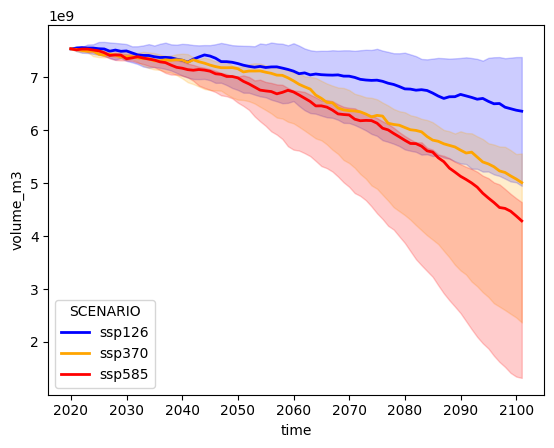

In [41]:
import seaborn as sns 
# this code might only work with seaborn v>=0.12
# seaborn always likes to have pandas dataframes
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()
sns.lineplot(x='time', y='volume_m3',
             hue='SCENARIO', # these are the dimension for the different colors 
             estimator='median', # here you could also choose the mean
             data=pd_total_volume,
             lw=2, # increase the linewidth a bit
             palette= color_dict, # let's use the same colors as before
             # for errorbar you could also choose another percentile range
             # see: https://seaborn.pydata.org/tutorial/error_bars.html
             # "90" means the range goes from the 5th to the 95th percentile
             # (50 would be the interquartile range, i.e., the same as two plots above)
             errorbar=('pi', 90) 
            );

In [29]:
pip install holoviews

  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 75.6 kB/s eta 0:00:00m eta 0:00:010:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.3 kB/s eta 0:00:00m eta 0:00:010:06:11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 79.1 kB/s eta 0:00:00m eta 0:00:020:00:12
Using cached markdown_it_py-3.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Note: you may need to restart the kernel to use updated packages.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
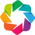

In [31]:
# Plotting
import holoviews as hv
import panel as pn
hv.extension('bokeh')
pn.extension()

In [32]:
def calculate_total_mean_and_std(ds, variable):
    mean = ds[variable].sum(dim='rgi_id',  # first sum up over all glaciers
                            skipna=True,
                            keep_attrs=True,
                            # important, need values for every glacier
                            min_count=len(ds_merged.rgi_id), 
                           ).mean(dim='GCM',  # afterwards calculate the mean of all GCMs
                                  skipna=True,
                                  keep_attrs=True,
                                 )
    std = ds[variable].sum(dim='rgi_id',  # first sum up over all glaciers 
                           skipna=True,
                           keep_attrs=True,
                           min_count=len(ds_merged.rgi_id), 
                          ).std(dim='GCM',  # afterwards calculate the std of all GCMs
                                skipna=True,
                                keep_attrs=True,
                               )
    return mean, std

In [33]:
# calculate mean and std with the previously defined function
total_volume_mean, total_volume_std = calculate_total_mean_and_std(ds_merged, 'volume')

# select only one SSP scenario
total_volume_mean_ssp585 = total_volume_mean.loc[{'SCENARIO': 'ssp585'}]

# plot a curve
x = total_volume_mean_ssp585.coords['time']
y = total_volume_mean_ssp585
hv.Curve((x, y),
         kdims=x.name,
         vdims=y.name,
        ).opts(xlabel=x.attrs['description'],
               ylabel=f"{y.attrs['description']} in {y.attrs['unit']}")

:Curve   [time]   (volume)

In [34]:
def get_single_curve(mean, std, ssp):
    color = color_dict[ssp] 
    mean_use = mean.loc[{'SCENARIO': ssp}]  # read out the mean of the SSP to plot 
    std_use = std.loc[{'SCENARIO': ssp}]  # read out the std of the SSP to plot
    time = mean.coords['time']  # get the time for the x axis
    
    return (hv.Area((time,  # plot std as an area
                     mean_use + std_use,  # upper boundary of the area
                     mean_use - std_use),  # lower boundary of the area
                    vdims=[mean_use.name, 'y2'],  # vdims for both boundaries
                    kdims='time',
                    label=ssp,
                   ).opts(alpha=0.2,
                          line_color=None,
                         ) *
            hv.Curve((time, mean_use),
                     vdims=mean_use.name,
                     kdims='time',
                     label=ssp,
                     
                    ).opts(line_color=color)
           ).opts(width=400,  # width of the total plot
                  height=400,  # height of the total plot
                  xlabel=time.attrs['description'],
                  ylabel=f"{mean_use.attrs['description']} in {mean_use.attrs['unit']}",
                 )

In [35]:
def overlay_scenarios(ds, variable):
    hmap = hv.HoloMap(kdims='Scenarios')   # create a HoloMap
    mean, std = calculate_total_mean_and_std(ds, variable)  # calculate mean and std for all SSPs using our previously defined function
    for ssp in all_scenario:
        hmap[ssp] = get_single_curve(mean, std, ssp)  # add a curve for each SSP to the HoloMap, using the SSP as a key (when you compare it do a dictonary)
    return hmap.overlay().opts(title=variable)  # create an overlay of all curves

In [36]:
all_plots = pn.Column(pn.Row(overlay_scenarios(ds_merged, 'volume'),
                             overlay_scenarios(ds_merged, 'area'),
                            ),
                      overlay_scenarios(ds_merged, 'melt_on_glacier'))

/home/usman/anaconda3/envs/oggm_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [37]:
all_plots

Column
    [0] Row
        [0] HoloViews(NdOverlay, height=400, sizing_mode='fixed', width=400)
        [1] HoloViews(NdOverlay, height=400, sizing_mode='fixed', width=400)
    [1] HoloViews(NdOverlay, height=400, sizing_mode='fixed', width=400)

In [38]:
all_plots.show()

Launching server at http://localhost:45523


In [39]:
plots_to_save = pn.panel(all_plots)
plots_to_save.save('GCM_runs.html', embed=True)